In [4]:
from optparse import Values

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")


In [5]:
df_customers = pd.read_csv("DataSet/customers.csv")
df_customers.head()

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
0,1,Dhruv Bansal,Female,2,City,Business Owner,358211.0,Married
1,2,Kabir Thakur,Female,47,City,Consultant,65172.0,Single
2,3,Kriti Mangal,Male,21,City,Freelancer,22378.0,Married
3,4,Sara Dwivedi,Male,24,Rural,Freelancer,33563.0,Married
4,5,Aarohi Negi,Male,48,City,Consultant,39406.0,Married


In [6]:
df_cs = pd.read_csv("DataSet/credit_profiles.csv")
df_trans = pd.read_csv("DataSet/transactions.csv")

In [7]:
df_cs.head()

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit
0,1,749,0.585171,19571.0,0.0,40000.0
1,2,587,0.107928,161644.0,2.0,1250.0
2,3,544,0.854807,513.0,4.0,1000.0
3,4,504,0.336938,224.0,2.0,1000.0
4,5,708,0.586151,18090.0,2.0,40000.0


In [8]:
df_trans.shape

(500000, 7)

Handling Null Values (Annual Income)

In [9]:
df_customers.describe()

,cust_id,age,annual_income
count,1000.000000,1000.000000,950.000000
mean,500.500000,36.405000,139410.314737
std,288.819436,15.666155,112416.802007
min,1.000000,1.000000,2.000000
25%,250.750000,26.000000,47627.500000
50%,500.500000,32.000000,112218.500000
75%,750.250000,46.000000,193137.500000
max,1000.000000,135.000000,449346.000000


In [10]:
df_customers.isnull().sum()

cust_id            0
name               0
gender             0
age                0
location           0
occupation         0
annual_income     50
marital_status     0
dtype: int64

In [11]:
df_customers.annual_income.isna()

0      False
1      False
2      False
3      False
4      False
       ...  
995     True
996    False
997    False
998     True
999    False
Name: annual_income, Length: 1000, dtype: bool

In [12]:
df_customers[df_customers.annual_income.isna()].head()

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
14,15,Isha Arora,Female,25,Rural,Artist,NaN,Married
82,83,Sanjana Singhal,Male,27,City,Freelancer,NaN,Single
97,98,Sia Batra,Male,47,Suburb,Business Owner,NaN,Married
102,103,Pooja Ganguly,Male,32,City,Data Scientist,NaN,Married
155,156,Krishna Trivedi,Male,24,City,Fullstack Developer,NaN,Married


In [13]:
df_customers.annual_income.median()

np.float64(112218.5)

In [14]:
df_customers[df_customers.occupation == "Artist"].annual_income.median()

np.float64(45794.0)

In [15]:
df_customers[df_customers.occupation == "Freelancer"].annual_income.median()

np.float64(46759.0)

In [16]:
df_customers[df_customers.occupation == "Data Scientist"].annual_income.median()

np.float64(135759.0)

In [17]:
occupation_wise_median  =df_customers.groupby("occupation").annual_income.median()
occupation_wise_median

occupation
Accountant              65265.0
Artist                  45794.0
Business Owner         261191.5
Consultant              58017.0
Data Scientist         135759.0
Freelancer              46759.0
Fullstack Developer     76774.0
Name: annual_income, dtype: float64

In [18]:
occupation_wise_median["Artist"]

np.float64(45794.0)

In [19]:
def get_median_val(row):
    if pd.isnull(row["annual_income"]):
        return occupation_wise_median(row["occupation"])
    else:
        return row["annual_income"]

get_median_val({"cust_id" : 3245 ,"occupation" : "Artist" ,"annual_income": 678})

678

In [20]:
df_customers["annual_income"] = df_customers.apply(
    lambda row: occupation_wise_median[row["occupation"]] if pd.isnull(row["annual_income"]) else row["annual_income"] ,
    axis =1)

In [21]:
df_customers.isnull().sum()

cust_id           0
name              0
gender            0
age               0
location          0
occupation        0
annual_income     0
marital_status    0
dtype: int64

In [22]:
df_customers.iloc[[14,82]]

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
14,15,Isha Arora,Female,25,Rural,Artist,45794.0,Married
82,83,Sanjana Singhal,Male,27,City,Freelancer,46759.0,Single


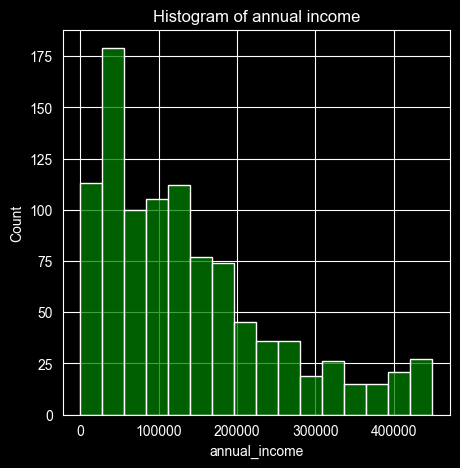

In [23]:
plt.figure(figsize=(5,5))
sns.histplot(df_customers["annual_income"],kde = False,color="green",label = 'Data')
plt.title("Histogram of annual income")
plt.show()

DATA CLEANING (Treating Outliers)

In [24]:
df_customers.describe()

,cust_id,age,annual_income
count,1000.000000,1000.000000,1000.000000
mean,500.500000,36.405000,138916.765500
std,288.819436,15.666155,110969.408643
min,1.000000,1.000000,2.000000
25%,250.750000,26.000000,48229.500000
50%,500.500000,32.000000,113416.000000
75%,750.250000,46.000000,192614.000000
max,1000.000000,135.000000,449346.000000


In [25]:
df_customers[df_customers.annual_income< 100]

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
31,32,Veer Gambhir,Male,50,City,Business Owner,50.0,Married
262,263,Veer Rathod,Male,53,Suburb,Business Owner,50.0,Married
316,317,Avinash Chauhan,Male,47,City,Consultant,50.0,Married
333,334,Samaira D'Souza,Female,29,City,Data Scientist,50.0,Married
340,341,Ridhi Rastogi,Female,33,Rural,Fullstack Developer,50.0,Married
543,544,Gauri Gupta,Male,54,City,Consultant,2.0,Married
592,593,Vivaan Pande,Female,32,City,Business Owner,50.0,Married
633,634,Aradhya Pandey,Male,26,City,Data Scientist,2.0,Married
686,687,Gauri Nanda,Male,40,City,Business Owner,2.0,Married
696,697,Avani Lalwani,Male,47,City,Consultant,20.0,Married


In [26]:
occupation_wise_median

occupation
Accountant              65265.0
Artist                  45794.0
Business Owner         261191.5
Consultant              58017.0
Data Scientist         135759.0
Freelancer              46759.0
Fullstack Developer     76774.0
Name: annual_income, dtype: float64

In [27]:
for index,row in df_customers.iterrows():
    if row['annual_income'] < 100:
        df_customers.at[index,"annual_income"] = occupation_wise_median[row["occupation"]]

In [28]:
df_customers[df_customers.annual_income<100]

,cust_id,name,gender,age,location,occupation,annual_income,marital_status


In [29]:
df_customers.loc[[31,36]]

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
31,32,Veer Gambhir,Male,50,City,Business Owner,261191.5,Married
36,37,Rishabh Rastogi,Male,39,Suburb,Data Scientist,135479.0,Single


DATA VISUALISATION (Annual Income)

In [30]:
avg_income_per_occupation = df_customers.groupby("occupation")["annual_income"].mean()
avg_income_per_occupation

occupation
Accountant              64123.562500
Artist                  45309.236842
Business Owner         268447.368512
Consultant              60703.154639
Data Scientist         137021.266304
Freelancer              76327.508772
Fullstack Developer     78727.972973
Name: annual_income, dtype: float64

In [31]:
avg_income_per_occupation.index

Index(['Accountant', 'Artist', 'Business Owner', 'Consultant',
       'Data Scientist', 'Freelancer', 'Fullstack Developer'],
      dtype='object', name='occupation')

In [32]:
avg_income_per_occupation.values

array([ 64123.5625    ,  45309.23684211, 268447.36851211,  60703.15463918,
       137021.26630435,  76327.50877193,  78727.97297297])

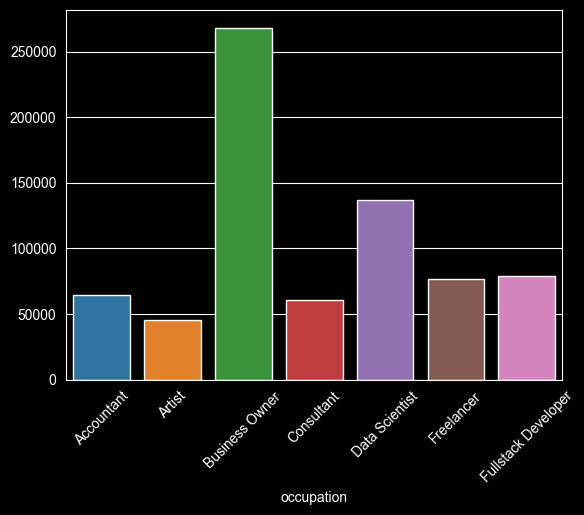

In [33]:
sns.barplot(x= avg_income_per_occupation.index, y =avg_income_per_occupation.values,palette="tab10")
plt.xticks(rotation=45)
plt.show()

Treat Oultiers in Age Coloumn

In [34]:
df_customers.age.describe()

count    1000.000000
mean       36.405000
std        15.666155
min         1.000000
25%        26.000000
50%        32.000000
75%        46.000000
max       135.000000
Name: age, dtype: float64

In [35]:
outliers = df_customers[(df_customers.age>80) | (df_customers.age < 15)]
outliers

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
0,1,Dhruv Bansal,Female,2,City,Business Owner,358211.0,Married
41,42,Manya Thakur,Male,110,City,Artist,7621.0,Married
165,166,Swara Mehtani,Female,1,City,Freelancer,39721.0,Single
174,175,Sneha Jaiswal,Male,110,City,Freelancer,23723.0,Married
222,223,Aaryan Bajaj,Male,110,Suburb,Freelancer,210987.0,Married
277,278,Amaira Dewan,Male,110,City,Consultant,96522.0,Single
295,296,Veer Anand,Male,1,Rural,Accountant,55254.0,Married
325,326,Yash Chatterjee,Male,110,City,Accountant,61021.0,Single
610,611,Advait Mangal,Male,135,Rural,Business Owner,444776.0,Married
692,693,Aarohi Dubey,Male,1,City,Business Owner,83045.0,Married


In [36]:
median_age = df_customers.groupby("occupation")["age"].median()
median_age

occupation
Accountant             31.5
Artist                 26.0
Business Owner         51.0
Consultant             46.0
Data Scientist         32.0
Freelancer             24.0
Fullstack Developer    27.5
Name: age, dtype: float64

In [37]:
for index ,row in outliers.iterrows():
    df_customers.at[index,"age"] = median_age[row["occupation"]]

In [38]:
df_customers[(df_customers.age<15) | (df_customers.age>80) ]

,cust_id,name,gender,age,location,occupation,annual_income,marital_status


In [43]:
df_customers.describe()

,cust_id,age,annual_income
count,1000.000000,1000.000000,1000.000000
mean,500.500000,35.541500,140483.548500
std,288.819436,12.276634,110463.002934
min,1.000000,18.000000,5175.000000
25%,250.750000,26.000000,49620.500000
50%,500.500000,32.000000,115328.000000
75%,750.250000,44.250000,195514.250000
max,1000.000000,64.000000,449346.000000


Data Visualisation (Age,Gender,Location)

In [40]:
df_customers.head()

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
0,1,Dhruv Bansal,Female,51.0,City,Business Owner,358211.0,Married
1,2,Kabir Thakur,Female,47.0,City,Consultant,65172.0,Single
2,3,Kriti Mangal,Male,21.0,City,Freelancer,22378.0,Married
3,4,Sara Dwivedi,Male,24.0,Rural,Freelancer,33563.0,Married
4,5,Aarohi Negi,Male,48.0,City,Consultant,39406.0,Married


In [45]:
bin_edges = [17,25,48,65]
bin_labels = ['18-25','26-48','49-65']

df_customers['age_group'] = pd.cut(df_customers["age"],bins=bin_edges, labels=bin_labels)
df_customers.head()

,cust_id,name,gender,age,location,occupation,annual_income,marital_status,age_group
0,1,Dhruv Bansal,Female,51.0,City,Business Owner,358211.0,Married,49-65
1,2,Kabir Thakur,Female,47.0,City,Consultant,65172.0,Single,26-48
2,3,Kriti Mangal,Male,21.0,City,Freelancer,22378.0,Married,18-25
3,4,Sara Dwivedi,Male,24.0,Rural,Freelancer,33563.0,Married,18-25
4,5,Aarohi Negi,Male,48.0,City,Consultant,39406.0,Married,26-48


In [50]:
age_group_counts = df_customers.age_group.value_counts(normalize = True)*100
age_group_counts

age_group
26-48    56.7
18-25    24.6
49-65    18.7
Name: proportion, dtype: float64

In [51]:
type(age_group_counts)

pandas.core.series.Series

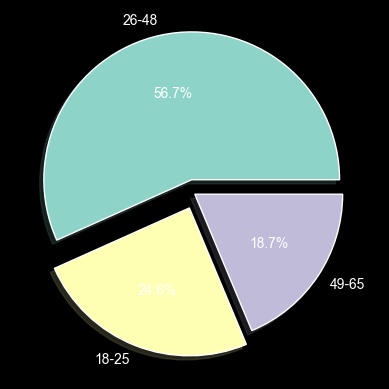

In [61]:
plt.pie(
    age_group_counts,
    labels=age_group_counts.index
    ,autopct='%1.1f%%',
    shadow=True,
     explode=(0.1,0.1,0))
plt.show()

In [62]:
df_customers.location.value_counts()

location
City      683
Suburb    232
Rural      85
Name: count, dtype: int64

In [64]:
df_customers.gender.value_counts()

gender
Male      674
Female    326
Name: count, dtype: int64

In [69]:
customer_location_gender = df_customers.groupby(['location','gender']).size()
customer_location_gender


location  gender
City      Female    226
          Male      457
Rural     Female     26
          Male       59
Suburb    Female     74
          Male      158
dtype: int64

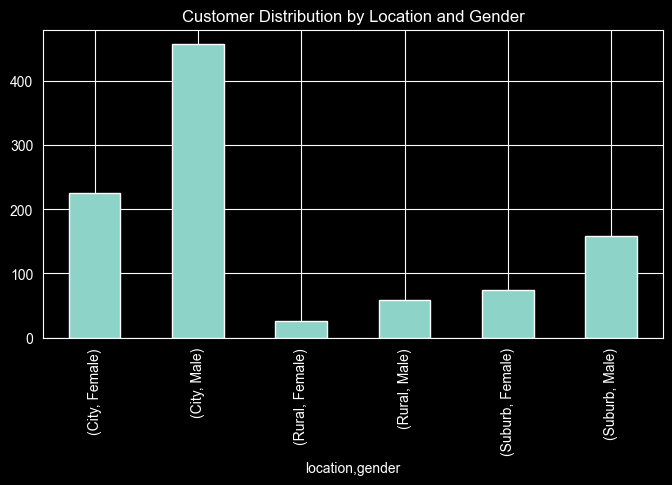

In [75]:
customer_location_gender.plot(kind='bar',stacked = True,
                              figsize=(8,4))
plt.title("Customer Distribution by Location and Gender")
plt.show()

Data Cleaning (Credit Score Table)

In [76]:
df_cs

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit
0,1,749,0.585171,19571.0,0.0,40000.0
1,2,587,0.107928,161644.0,2.0,1250.0
2,3,544,0.854807,513.0,4.0,1000.0
3,4,504,0.336938,224.0,2.0,1000.0
4,5,708,0.586151,18090.0,2.0,40000.0
...,...,...,...,...,...,...
999,996,564,0.702963,688.0,2.0,1250.0
1000,997,774,0.465462,17139.0,0.0,60000.0
1001,998,529,0.585856,386.0,3.0,1000.0
1002,999,725,0.249670,6973.0,2.0,40000.0


In [77]:
df_cs.shape

(1004, 6)

In [79]:
df_cs[df_cs['cust_id'].duplicated(keep=False)]

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit
516,517,308,NaN,NaN,NaN,NaN
517,517,308,0.113860,33.0,3.0,500.0
569,569,344,NaN,NaN,NaN,NaN
570,569,344,0.112599,37.0,0.0,500.0
607,606,734,NaN,NaN,NaN,NaN
608,606,734,0.193418,4392.0,1.0,40000.0
664,662,442,NaN,NaN,NaN,NaN
665,662,442,0.856039,266.0,2.0,500.0


In [82]:
df_cs_clean1 = df_cs.drop_duplicates(subset='cust_id',keep='last')
df_cs_clean1.shape

(1000, 6)

In [85]:
df_cs_clean1[df_cs_clean1['cust_id'].duplicated(keep=False)]

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit


In [87]:
df_cs_clean1.isnull().sum()

cust_id                            0
credit_score                       0
credit_utilisation                 0
outstanding_debt                   0
credit_inquiries_last_6_months     0
credit_limit                      65
dtype: int64

In [88]:
df_cs_clean1[df_cs_clean1.credit_limit.isnull()]

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit
10,11,679,0.557450,9187.0,2.0,NaN
35,36,790,0.112535,4261.0,1.0,NaN
37,38,514,0.296971,238.0,2.0,NaN
45,46,761,0.596041,24234.0,2.0,NaN
64,65,734,0.473715,13631.0,0.0,NaN
...,...,...,...,...,...,...
912,909,479,0.487555,320.0,3.0,NaN
931,928,311,0.832244,316.0,2.0,NaN
948,945,526,0.272734,227.0,1.0,NaN
954,951,513,0.175914,131.0,3.0,NaN


In [89]:
df_cs_clean1.credit_limit.value_counts()

credit_limit
500.0      229
60000.0    186
40000.0    137
1500.0     100
1000.0      90
750.0       76
1250.0      75
20000.0     42
Name: count, dtype: int64

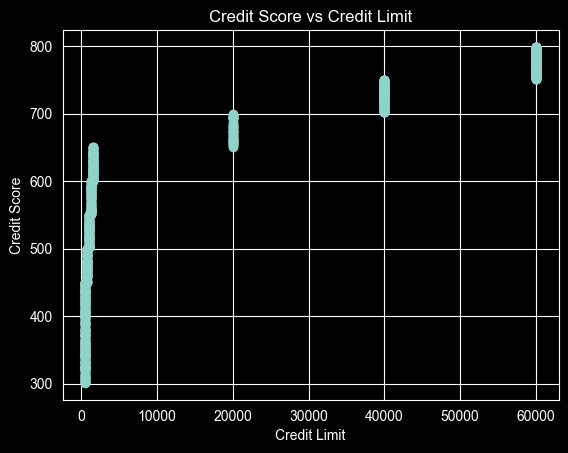

In [91]:
plt.scatter(df_cs_clean1['credit_limit'],df_cs_clean1['credit_score'])
plt.title('Credit Score vs Credit Limit')
plt.xlabel('Credit Limit')
plt.ylabel('Credit Score')
plt.show()

In [102]:
bin_ranges = [300,450,500,550,600,650,700,750,800]
bin_labels = [f'{start}-{end-1}' for start ,end in zip(bin_ranges,bin_ranges[1:])]
df_cs_clean1['credit_score_range'] = pd.cut(df_cs_clean1['credit_score'],bins=bin_ranges,labels=bin_labels,include_lowest=True,right=False)

df_cs_clean1.head()

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range
0,1,749,0.585171,19571.0,0.0,40000.0,700-749
1,2,587,0.107928,161644.0,2.0,1250.0,550-599
2,3,544,0.854807,513.0,4.0,1000.0,500-549
3,4,504,0.336938,224.0,2.0,1000.0,500-549
4,5,708,0.586151,18090.0,2.0,40000.0,700-749


In [103]:
df_cs_clean1[df_cs_clean1.credit_score_range == "700-749"]

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range
0,1,749,0.585171,19571.0,0.0,40000.0,700-749
4,5,708,0.586151,18090.0,2.0,40000.0,700-749
6,7,747,0.523965,15544.0,4.0,40000.0,700-749
16,17,702,0.894423,18444.0,0.0,40000.0,700-749
27,28,729,0.149748,3453.0,2.0,40000.0,700-749
...,...,...,...,...,...,...,...
969,966,720,0.203742,6159.0,4.0,40000.0,700-749
970,967,739,0.845474,23929.0,4.0,40000.0,700-749
991,988,739,0.435891,9283.0,4.0,40000.0,700-749
994,991,709,0.718484,15473.0,4.0,40000.0,700-749


In [107]:
mode_df = df_cs_clean1.groupby("credit_score_range")['credit_limit'].agg(lambda x : x.mode().iloc[0])
mode_df

credit_score_range
300-449      500.0
450-499      750.0
500-549     1000.0
550-599     1250.0
600-649     1500.0
650-699    20000.0
700-749    40000.0
750-799    60000.0
Name: credit_limit, dtype: float64

In [108]:
df_cs_clean1[df_cs_clean1.credit_limit.isnull()].sample(3)

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range
505,506,722,0.745946,25243.0,3.0,NaN,700-749
64,65,734,0.473715,13631.0,0.0,NaN,700-749
258,259,427,0.339428,136.0,4.0,NaN,300-449


In [112]:
df_clean2 =pd.merge(df_cs_clean1,mode_df,on='credit_score_range',suffixes=('',"_mode"))
df_clean2.sample(3)

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range,credit_limit_mode
985,986,425,0.178470,56.0,4.0,500.0,300-449,500.0
754,755,545,0.848028,483.0,3.0,1000.0,500-549,1000.0
317,318,785,0.619822,26922.0,4.0,60000.0,750-799,60000.0


In [113]:
df_clean2[df_clean2.credit_limit.isnull()].sample(3)

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range,credit_limit_mode
351,352,736,0.367879,9916.0,2.0,NaN,700-749,40000.0
380,381,626,0.216894,235.0,0.0,NaN,600-649,1500.0
274,275,798,0.491995,19365.0,4.0,NaN,750-799,60000.0


In [119]:
df_cs_clean3 = df_clean2.copy()
df_cs_clean3.fillna(df_cs_clean3['credit_limit_mode'],inplace = True)
df_cs_clean3

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range,credit_limit_mode
0,1,749,0.585171,19571.0,0.0,40000.0,700-749,40000.0
1,2,587,0.107928,161644.0,2.0,1250.0,550-599,1250.0
2,3,544,0.854807,513.0,4.0,1000.0,500-549,1000.0
3,4,504,0.336938,224.0,2.0,1000.0,500-549,1000.0
4,5,708,0.586151,18090.0,2.0,40000.0,700-749,40000.0
...,...,...,...,...,...,...,...,...
995,996,564,0.702963,688.0,2.0,1250.0,550-599,1250.0
996,997,774,0.465462,17139.0,0.0,60000.0,750-799,60000.0
997,998,529,0.585856,386.0,3.0,1000.0,500-549,1000.0
998,999,725,0.249670,6973.0,2.0,40000.0,700-749,40000.0


In [116]:
df_cs_clean3.shape

(1000, 8)

In [120]:
df_cs_clean3.isnull().sum()

cust_id                            0
credit_score                       0
credit_utilisation                 0
outstanding_debt                   0
credit_inquiries_last_6_months     0
credit_limit                      65
credit_score_range                 0
credit_limit_mode                  0
dtype: int64

In [121]:
df_cs_clean3.head()

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range,credit_limit_mode
0,1,749,0.585171,19571.0,0.0,40000.0,700-749,40000.0
1,2,587,0.107928,161644.0,2.0,1250.0,550-599,1250.0
2,3,544,0.854807,513.0,4.0,1000.0,500-549,1000.0
3,4,504,0.336938,224.0,2.0,1000.0,500-549,1000.0
4,5,708,0.586151,18090.0,2.0,40000.0,700-749,40000.0
